In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns

plt.rcParams["font.family"] = "serif"
# plt.rcParams['figure.constrained_layout.use'] = False

# plt.rcParams.update({
#     "font.size": 15,              # Base font size
#     "axes.titlesize": 19,         # Title font size
#     "axes.labelsize": 18,         # Axis label size
#     "xtick.labelsize": 17,        # X tick label size
#     "ytick.labelsize": 17,        # Y tick label size
#     "legend.fontsize": 17,        # Legend font size
#     "figure.titlesize": 19        # Figure title size
# })

# --- User-configurable section ---
# ENTITY = "faisal-ahmed-a-m"
ENTITY = "glen-berseth"

api = wandb.Api()
# this is all the runs in the wandb project
# runs = api.runs(f"{ENTITY}/{PROJECT}")
plots_folder="final_results"
os.makedirs(plots_folder, exist_ok=True)

In [2]:
# Helper methods
def extract_results(runs, config, x_metric="step", 
                    y_metric="training/num_visited_unique_state",
                      n_points=None, aggregate=False, env_name_key="env_name",
                      training_steps=None):
    # method for filtering the runs for specific hyperparameters
    filtered_runs = []
    for r in runs:
        cfg = r.config
        # print(cfg.)
        # print((cfg.get("gamma_schedule")))
        # print((config.get("gamma_schedule")))
        # print(({k:cfg.get(k) == config.get(k) for k in config}))
        # print(all([cfg.get(k) == config.get(k) for k in config]))
        # import pdb;pdb.set_trace()
        # print(cfg)
        # print(config)
        if cfg.get(env_name_key) == config.get(env_name_key):
            print(all([cfg.get(k) == config.get(k) for k in config]))
            if all([cfg.get(k) == config.get(k) for k in config]):
                # print([cfg.get(k) == config.get(k) != None for k in config])
                print('found run!')
                print(config)
                # print(r)
                history = r.history()
                # print(type(history))
                if training_steps:
                    x_array = np.linspace(0, training_steps, len(history[y_metric].to_numpy()))
                else:
                    x_array = history[x_metric].to_numpy()
                if n_points:
                    inds = np.linspace(0,  len(history[y_metric].to_numpy())-1, num=n_points, dtype=np.int64)
                    x_array = np.linspace(0, training_steps, n_points)
                    # print(inds)
                    y_array = history[y_metric].to_numpy()[inds]
                else:
                    y_array = history[y_metric].to_numpy()
                filtered_runs.append(
                    {
                        x_metric: x_array,
                        y_metric: y_array
                    }
                )
    if aggregate:
        y_metrc_values = []
        for f_run in filtered_runs:
            y_metrc_values.append(f_run[y_metric])
            # print(f_run[y_metric].shape)
        
        aggregated_run = {
            x_metric: x_array, # values are the same 
            f"{y_metric}_mean": np.mean(y_metrc_values, axis=0),
            f"{y_metric}_std": np.std(y_metrc_values, axis=-0),
        }
        return x_array, aggregated_run
    return filtered_runs

def plot_results(x, y_mean, y_std, legend, color):
    ax= plt.plot(x, y_mean, label=legend, markersize=4, linewidth=1.5, color=color)
    plt.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2, color=color)
    return ax

def set_plot_annotations(title, x_label, y_label):
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)


def process_legend():
    plt.legend()


In [16]:
# Extract the results you want to plot
# env_name="ant_hardest_maze"
# env_name="humanoid_u_maze"
# env_names=["ant_hardest_maze", "humanoid_u_maze", "arm_binpick_hard"]
# PROJECTS = ["ctec_same_trajectory_negatives", "ctec_same_trajectory_negatives", "ctec_same_trajectory_negatives"]
env_names=["Craftax-Classic-Symbolic-v1"]
# env_names=["Craftax-Classic-Symbolic-v1"]
PROJECTS=["ctec_craftax_repeated_negatives", "ctec_craftax_repeated_negatives", "ctec_craftax_repeated_negatives"]
# PROJECTS = ["crl_craftax_classic_bug_fixed_final", "crl_rnn_craftax_classic_bug_fixed_final"]
extracted_results_all = []
n_points = 250
training_steps = 500_000_000
use_complete_future_state = False
for PROJECT, env_name in zip(PROJECTS, env_names):
    print(env_name)
    print(PROJECT)
    if "Craftax" in env_name:
        training_steps =1000_000_000
        x_metric = "_step"
        y_metric = "achievements"
        env_name_key = "ENV_NAME"
        run_configs = {
            "ctec_craftax_repeated_negatives": 
            [{"MODEL": "crl_ppo_rnn", "REPETITION_FACTOR": 1, "GAMMA_CL": 0.3, env_name_key: env_name},
            {"MODEL": "crl_ppo_rnn", "REPETITION_FACTOR": 2, "GAMMA_CL": 0.3, env_name_key: env_name},
            {"MODEL": "crl_ppo_rnn", "REPETITION_FACTOR": 4, "GAMMA_CL": 0.3, env_name_key: env_name},
            ],

            # "ctec_craftax_repeated_negatives": 
            # [{"MODEL": "crl_ppo_rnn", env_name_key: env_name},
            # {"MODEL": "ppo_e3b", env_name_key: env_name},
            # {"MODEL": "ppo_rnd", env_name_key: env_name},
            # {"MODEL": "ppo_icm", env_name_key: env_name},],
            
            "crl_rnn_craftax_classic_bug_fixed_final": 
            [{"MODEL": "crl_ppo_rnn", env_name_key: env_name},
            {"USE_RND": False,"USE_E3B": True, "USE_ICM": True, env_name_key: env_name},
            {"USE_RND": True,"USE_E3B": False, "USE_ICM": False, env_name_key: env_name},
            {"USE_RND": False,"USE_E3B": False, "USE_ICM": True, env_name_key: env_name},
            {"MODEL": "random_agent", env_name_key: env_name},
            ], 
            
            "craftax_crl_explore_ablation_sim_funs_2":
            [
                {"SIMILARITY_MEASURE": "l1", env_name_key: env_name},
                {"SIMILARITY_MEASURE": "l2", env_name_key: env_name},
                {"SIMILARITY_MEASURE": "l2_no_sqrt", env_name_key: env_name},
                {"SIMILARITY_MEASURE": "dot", env_name_key: env_name},
            ],
            "crl_explore_ablation_repr_norm": [
                {"USE_NORMALIZE_REPR": True, env_name_key: env_name},
                {"USE_NORMALIZE_REPR": False, env_name_key: env_name},
            ],
            "craftax_crl_explore_ablation_contr_losses": [
                {"CONTRASTIVE_LOSS": "infonce", env_name_key: env_name},
                {"CONTRASTIVE_LOSS": "symmetric_infonce", env_name_key: env_name},
                {"CONTRASTIVE_LOSS": "binary", env_name_key: env_name},
                {"CONTRASTIVE_LOSS": "flatnce", env_name_key: env_name},
                {"CONTRASTIVE_LOSS": "fb", env_name_key: env_name},
            ]
            
        }
        runs = api.runs(f"{ENTITY}/{PROJECT}")
        extracted_results = [extract_results(runs, run_config, x_metric=x_metric, 
                                            y_metric=y_metric , n_points=n_points, aggregate=True, 
                                            env_name_key=env_name_key, training_steps=training_steps) for run_config in run_configs[PROJECT]]
        # extracted_results_all.append((x_values, extracted_results))
    else:
        x_metric = "step"
        y_metric = "training/num_visited_unique_state"
        env_name_key = "env_name"
        if "arm" in env_name:
            training_steps = 250_000_000
        # env_name = "Craftax-Classic-Symbolic-v1"
        # env_name_key = "ENV_NAME"
        # specify the hyperparams for the runs you want to extract
        run_configs = [
            {"model":"ctec_sac", "use_complete_future_state": True, "repetition_factor":1, "gamma_schedule": None, env_name_key: env_name},
            {"model":"ctec_sac", "use_complete_future_state": True, "repetition_factor":2, "gamma_schedule": None, env_name_key: env_name},
            {"model":"ctec_sac", "use_complete_future_state": True, "repetition_factor":4, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"ctec_sac", "use_complete_future_state": True, "temp_value":5, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"ctec_sac", "use_complete_future_state": True, "temp_value":10, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"ctec_sac", "use_complete_future_state": True, "discounting_cl":0.3, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"ctec_sac", "use_complete_future_state": True, "discounting_cl":0.3, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"crl_sac", "use_complete_future_state": True, "discounting_cl":1, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"crl_sac", "use_complete_future_state": True, "discounting_cl":0.99, "gamma_schedule_start": 0.1, "gamma_schedule": "exponential", env_name_key: env_name},
            # {"model":"crl_sac", "use_complete_future_state": True, "discounting_cl":0.99, "gamma_schedule_start": 0.9, "gamma_schedule": "exponential", env_name_key: env_name},
            # {"model":"crl_sac", "use_complete_future_state": use_complete_future_state, "discounting_cl":0.99, "use_mono_critic": None, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"crl_sac", "use_complete_future_state": True, "discounting_cl":0.99, "use_mono_critic": None, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"apt_sac", "use_complete_future_state": use_complete_future_state, env_name_key: env_name},
            # {"model":"apt_sac", "use_complete_future_state": True, env_name_key: env_name},
            # {"model":"rnd", "use_complete_future_state": use_complete_future_state, env_name_key: env_name},
            # {"model":"rnd", "use_complete_future_state": True, env_name_key: env_name},
            # {"model":"icm", "use_complete_future_state": use_complete_future_state, env_name_key: env_name},
            # {"model":"icm", "use_complete_future_state": True, env_name_key: env_name},
            # {"model":"random_policy", "use_complete_future_state": True, env_name_key: env_name},
            # {"model":"random_policy", "use_complete_future_state": True, env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "energy_fn": "l1", env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "energy_fn": "l2", env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "energy_fn": "l2_no_sqrt", env_name_key: e/nv_name},
            # {"logsumexp_penalty_coeff": 0.1, "energy_fn": "dot", env_name_key: env_name}
            # {"use_complete_future_state": False, "normalize_repr": True, env_name_key: env_name},
            # {"use_complete_future_state": False, "normalize_repr": False, env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "contr_loss": "infonce", env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "contr_loss": "symmetric_infonce", env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "contr_loss": "binary", env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "contr_loss": "flatnce", env_name_key: env_name},
            # {"logsumexp_penalty_coeff": 0.1, "contr_loss": "fb", env_name_key: env_name}
            # {"model":"crl_sac", "use_complete_future_state": True, "discounting_cl":0.99, "use_mono_critic": None, "gamma_schedule": None, env_name_key: env_name},
            # {"model":"crl_sac", "use_complete_future_state": False, "discounting_cl":0.99, "use_mono_critic": True, env_name_key: env_name},

            ### for mode seeking vs mode covering
            # {"model":"crl_sac", "use_complete_future_state": use_complete_future_state, "discounting_cl":0.99, "use_mono_critic": False, "gamma_schedule": None, env_name_key: env_name, "mode_covering_rwd": False, "mode_seeking_rwd": True},
            # {"model":"crl_sac", "use_complete_future_state": use_complete_future_state, "discounting_cl":0.99, "use_mono_critic": False, "gamma_schedule": None, env_name_key: env_name, "mode_covering_rwd": True, "mode_seeking_rwd": False},
            ]


        runs = api.runs(f"{ENTITY}/{PROJECT}")
        extracted_results = [extract_results(runs, run_config, x_metric=x_metric, 
                                            y_metric=y_metric , n_points=n_points, aggregate=True, 
                                            env_name_key=env_name_key, training_steps=training_steps) for run_config in run_configs]
    x_values = extracted_results[0][0]
    extracted_results_all.append((x_values, extracted_results))
        

Craftax-Classic-Symbolic-v1
ctec_craftax_repeated_negatives
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
found run!
{'MODEL': 'crl_ppo_rnn', 'REPETITION_FACTOR': 1, 'GAMMA_CL': 0.3, 'ENV_NAME': 'Craftax-Classic-Symbolic-v1'}
True
found run!
{'MODEL': 'crl_ppo_rnn', 'REPETITION_FACTOR': 1, 'GAMMA_CL': 0.3, 'ENV_NAME': 'Craftax-Classic-Symbolic-v1'}
True
found run!
{'MODEL': 'crl_ppo_rnn', 'REPETITION_FACTOR': 1, 'GAMMA_CL': 0.3, 'ENV_NAME': 'Craftax-Classic-Symbolic-v1'}
True
found run!
{'MODEL': 'crl_ppo_rnn', 'REPETITION_FACTOR': 1, 'GAMMA_CL': 0.3, 'ENV_NAME': 'Craftax-Classic-Symbolic-v1'}
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
found run!
{'MODEL': 'crl_ppo_rnn', 'REPETITION_FACTOR': 2, 'GAMMA_CL': 0.3, 'ENV_NAME': 'Craftax-Classic-Symbolic-v1'}
True
found run!
{'MODEL': 'crl_pp

In [15]:
len(extracted_results_all[1])

2

In [10]:
def generate_df_for_barplot(filtered_runs, env_names, agents, complete_future_state=False, y_metric="training/num_visited_unique_state"):
    final_values = []
    for j, env_name in enumerate(env_names):
        all_runs = filtered_runs[j][1]
        for i, agent in enumerate(agents):
            agent_runs = all_runs[i]
            for agent_run in agent_runs:
                y_values = agent_run[y_metric]
                final_values.append(
                    {
                        "env_name": env_name,
                        "complete future state": complete_future_state,
                        "state coverage": y_values[-1],
                        "agent": agent, 

                    }
                )
    return final_values

In [170]:
extracted_results_all = extrac_all_Resutls(False)
agents = ["C-TeC", "APT", "RND", "ICM", "Random policy"]
env_names=["Ant hardest maze", "Humanoid u maze", "Arm binpick hard"]
df_partial_fs = pd.DataFrame(generate_df_for_barplot(extracted_results_all, env_names, agents, False, ))
extracted_results_all = extrac_all_Resutls(True)
df_full_fs = pd.DataFrame(generate_df_for_barplot(extracted_results_all, env_names, agents, True, ))
final_df = pd.concat([df_partial_fs, df_full_fs])

ant_hardest_maze
ant_hardest_maze_paper_final
humanoid_u_maze
humanoid_u_maze_paper_final
arm_binpick_hard
arm_binpick_hard_paper_final
ant_hardest_maze
ant_hardest_maze_paper_final
humanoid_u_maze
humanoid_u_maze_paper_final
arm_binpick_hard
arm_binpick_hard_paper_final


NameError: name 'final_df' is not defined

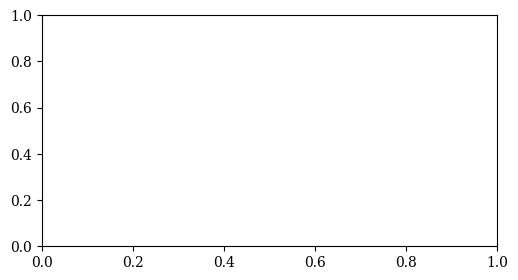

In [16]:
plt.figure(figsize=(20, 3))
for j, env_name in enumerate(env_names):
    plt.subplot(1,len(env_names), j+1)
    df_for_env = final_df[final_df["env_name"] == env_name]
    if env_name == "Ant hardest maze":
        ax = sns.barplot(data=df_for_env, x="agent", y="state coverage", hue="complete future state", palette=sns.color_palette("Paired"))
    else:
        ax = sns.barplot(data=df_for_env, x="agent", y="state coverage", hue="complete future state", palette=sns.color_palette("Paired"), legend=None)
    plt.title(env_name)
    if j == 0:
        plt.ylabel("# Visited States", fontsize=fontSize)
    else:
        plt.ylabel("", fontsize=fontSize)
    bars = ax.patches
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Try changing nbins
    fontSize = 17.3
    plt.title(env_name, fontweight='bold', fontsize=fontSize)
    plt.xlabel("Agent", fontsize=fontSize)
    plt.grid(which ='major', alpha = 0.4)
    ax.tick_params(axis='x', labelsize=12)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=12)

plt.savefig(f"{plots_folder}/state_coverage_barplot.pdf", dpi=300, bbox_inches='tight')
plt.savefig(f"{plots_folder}/state_coverage_barplot.png", dpi=300, bbox_inches='tight')

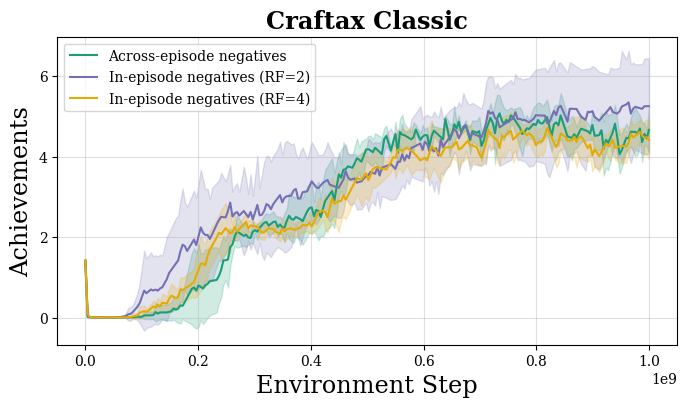

In [22]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


plot_labels={"step": "Environment Step",
         "training/num_visited_unique_state": "# Visited States",
         "training/logits_var": "Representations Variance",
         "_step": "Environment Step", 
         "achievements": "Achievements"}

colors = [(0.10588235294117647, 0.6196078431372549, 0.4666666666666667, 1.0), # CRL 
          (0.4588235294117647, 0.4392156862745098, 0.7019607843137254, 1.0),  # RND
          (0.9019607843137255, 0.6705882352941176, 0.00784313725490196, 1.0),  # ICM
          (0.6509803921568628, 0.4627450980392157, 0.11372549019607843, 1.0), # apt
          (0.4, 0.4, 0.4, 1.0), # random agent
          ] 
n_plots = len(run_configs)
plots_colors = colors[:n_plots]


# plt.figure(figsize=(20,4)) # figure size for the robotics experiments (fig 4 and 5 in the paper)
plt.figure(figsize=(8,4))
for j, (x_values, extracted_results) in enumerate(extracted_results_all):
    # print(j)
    legend_handles = []
    env_name = env_names[j]
    title = " ".join(env_name.capitalize().split("_"))
    if "Craftax" in env_name:
        title = "Craftax Classic"
        x_metric = "_step"
        y_metric = "achievements"
        if j == 1:
            title += " (With Recurrent Policies)"
    else:
        x_metric = "step"
        # y_metric = "training/num_visited_unique_state"
    x_label=plot_labels[x_metric]
    y_label=plot_labels[y_metric]
        
        # if j == 1:
        #     title += " (W/ Recurrent Policy)"
    
    # legends = ["W/ normalization", "W/O normalization"]
    # legends = ["InfoNCE", "Symmetric InfoNCE", "NCE (Binary)", "FlatNCE", "FB"]
    # print(j)
    plt.subplot(1,len(env_names), j+1)
    # legends = ["C-TeC (ours)", "APT", "RND", "ICM", "Random Policy"]
    # legends = ["C-TeC (ours)", "APT", "RND", "ICM", "Random Policy"]
    # legends = ["C-TeC (ours)", "APT", "RND", "ICM", "Random Policy"]
    # legends = ["L1", "L2", "L2 W/O sqrt", "Dot product"]
    # legends = ["Reverse KL (Mode-Seeking)", "Forward KL (Mean-Seeking)"]
    # legends = ["InfoNCE", "Symmetric InfoNCE", "NCE (Binary)", "FlatNCE", "FB"]
    # legends = ["C-TeC"]
    # legends = ["C-TeC ($\\tau=1$)", "C-TeC ($\\tau=0.5$)", "C-TeC ($\\tau=0.1$)", "C-TeC ($\\tau=5$)", "C-TeC ($\\tau=10$)"]    
    legends = ["Across-episode negatives", "In-episode negatives (RF=2)", "In-episode negatives (RF=4)"]    
    for i in range(len(legends)):
        color = colors[i]
        legend = legends[i]
        _, results = extracted_results[i]
        # print(results.keys())
        if "Random" in legend:
            plot_results(x_values, np.ones_like(x_values)*2.35, np.ones_like(x_values)*0.15, legend=legend, color=color)
        else:
            
            if np.isnan(results[f"{y_metric}_mean"]).any():
                nan_indices = np.isnan(results[f"{y_metric}_mean"])
                not_nan_indices = ~nan_indices
                interp_values = np.interp(
                    np.flatnonzero(nan_indices),
                    np.flatnonzero(not_nan_indices),
                    results[f"{y_metric}_mean"][not_nan_indices]
                )
                results[f"{y_metric}_mean"][nan_indices] = interp_values
                # same for std
                nan_indices = np.isnan(results[f"{y_metric}_std"])
                not_nan_indices = ~nan_indices
                interp_values = np.interp(
                    np.flatnonzero(nan_indices),
                    np.flatnonzero(not_nan_indices),
                    results[f"{y_metric}_std"][not_nan_indices]
                )
                results[f"{y_metric}_std"][nan_indices] = interp_values
                # results[f"{y_metric}_mean"] = results[f"{y_metric}_mean"].interpolate(method='linear')
                # results[f"{y_metric}s"] = results[f"{y_metric}_mean"].interpolate(method='linear')
            plot_results(x_values, results[f"{y_metric}_mean"], results[f"{y_metric}_std"], legend=legend, color=color)
        ax = plt.gca()
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Try changing nbins
        handle = Line2D([0], [0], color=color, label=legends[i], linewidth=2, markersize=5,)
        legend_handles.append(handle)
    fontSize = 17.3
    plt.title(title, fontweight='bold', fontsize=fontSize)
    plt.xlabel(x_label, fontsize=fontSize)
    plt.grid(which ='major', alpha = 0.4)
    # Save handle for legend
    
    # print(i)
    if j==0:
        plt.ylabel(y_label, fontsize=fontSize)
        # plt.legend()
        # process_legend()
    elif "Craftax" in env_name and j==0:
        plt.ylabel(y_label, fontsize=fontSize)
    # plt.tight_layout()




# plt.subplot(2,3, j+1)
# plt.legend(handles=legend_handles,loc='lower center', bbox_to_anchor=(-3.75, -0.5, 10, 1), ncol=5, fontsize="xx-large")
# plt.legend(handles=legend_handles,loc='center right', bbox_to_anchor=(-8.5, -0.0, 10, 1), ncol=1, fontsize="xx-large")
plt.legend()
# plt.tight_layout()
# plt.tight_layout(rect=[0, 0.05, 1, 1])
# file_name = "All_robotics_envs_ctec_coverage_non_complete_future_states"
# file_name=f"energy_fn_ablation"
# file_name=f"normalizing_contr_loss_ablation"
file_name = "ctec_negs_sampling_craftax"
# file_name = "craftax_results"
plt.savefig(f"{plots_folder}/{file_name}.png", dpi=200, bbox_inches='tight')
plt.savefig(f"{plots_folder}/{file_name}.pdf", dpi=200, bbox_inches='tight')


# fig_legend = plt.figure(figsize=(10, 1))
# fig_legend.legend(handles=legend_handles, loc="center", ncol=5)

# fig_legend.savefig(f"{plots_folder}/{file_name}_legend_only.pdf", dpi=300, bbox_inches='tight')
# fig_legend.savefig(f"{plots_folder}/{file_name}_legend_only.png", dpi=300, bbox_inches='tight')

In [20]:

def reorder_df_for_env(df, agents_order):
    new_df = []
    for agent in agents_order:
        for _, row in df.iterrows():
            if agent in row["agent"].lower():
                new_df.append(row.to_dict())
    return pd.DataFrame(new_df)

/tmp/ipykernel_3466027/2738891095.py:8: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  ax = sns.barplot(data=df_for_env, x="agent", y="state Coverage mean", hue="complete future state", palette=sns.color_palette("Paired"))
/tmp/ipykernel_3466027/2738891095.py:10: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  ax = sns.barplot(data=df_for_env, x="agent", y="state Coverage mean", hue="complete future state", palette=sns.color_palette("Paired"), legend=None)
/tmp/ipykernel_3466027/2738891095.py:10: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  ax = sns.barplot(data=df_for_env, x="agent", y="state Coverage mean", hue="complete future state", palette=sns.color_palette("Paired"), legend=None)


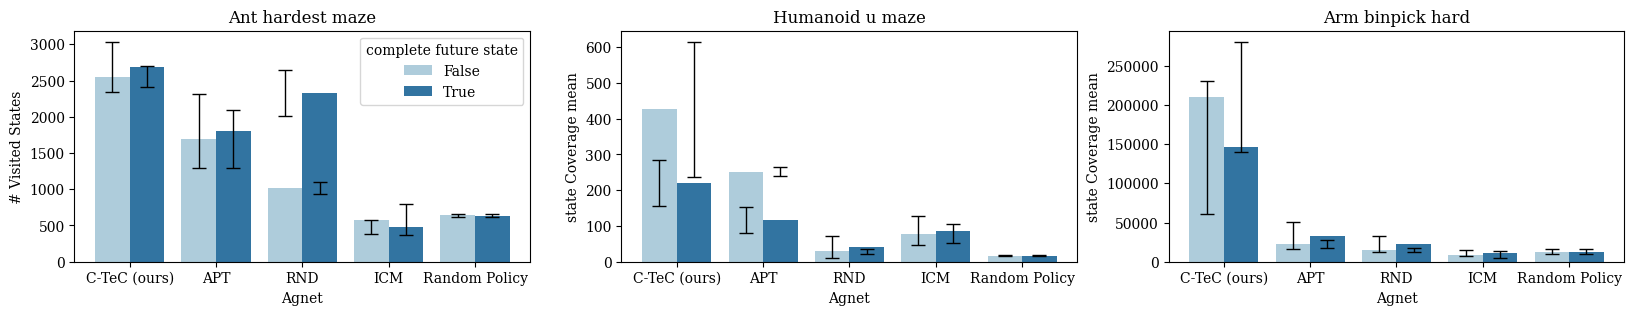

In [93]:
df_for_env

,agent,env_name,complete future state,state Coverage mean,state Coverage std
0,C-TeC (ours),Arm binpick hard,True,145720.777778,84412.750436
1,C-TeC (ours),Arm binpick hard,False,210168.800000,70427.651968
2,APT,Arm binpick hard,True,33323.000000,16801.753208
3,APT,Arm binpick hard,False,22529.333333,4666.869388
4,RND,Arm binpick hard,True,22963.400000,10150.251457
5,RND,Arm binpick hard,False,14878.800000,2643.835956
6,ICM,Arm binpick hard,True,11095.200000,4318.708344
7,ICM,Arm binpick hard,False,9088.428571,4262.568604
8,Random Policy,Arm binpick hard,True,12653.800000,2965.909736
9,Random Policy,Arm binpick hard,False,12661.400000,2973.414374


IndexError: list index out of range

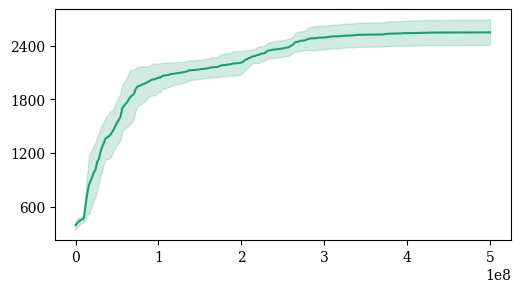

In [10]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


plot_labels={"step": "Environment Step",
         "training/num_visited_unique_state": "# Visited States",
         "_step": "Environment Step", 
         "achievements": "Achievements"}

colors = [(0.10588235294117647, 0.6196078431372549, 0.4666666666666667, 1.0), # CRL 
          (0.4588235294117647, 0.4392156862745098, 0.7019607843137254, 1.0),  # RND
          (0.9019607843137255, 0.6705882352941176, 0.00784313725490196, 1.0),  # ICM
          (0.6509803921568628, 0.4627450980392157, 0.11372549019607843, 1.0), # apt
          (0.4, 0.4, 0.4, 1.0), # random agent
          ] 
n_plots = len(run_configs)
plots_colors = colors[:n_plots]


plt.figure(figsize=(20,3)) # figure size for the robotics experiments (fig 4 and 5 in the paper)
# plt.figure(figsize=(6,3))
for j, (x_values, extracted_results) in enumerate(extracted_results_all):
    # print(j)
    legend_handles = []
    env_name = env_names[j]
    title = " ".join(env_name.capitalize().split("_"))
    if "Craftax" in env_name:
        title = "Craftax Classic"
        x_metric = "_step"
        y_metric = "achievements"
        # if j == 1:
        #     title += " (With Recurrent Policies)"
    else:
        x_metric = "step"
        y_metric = "training/num_visited_unique_state"
    x_label=plot_labels[x_metric]
    y_label=plot_labels[y_metric]
        
        # if j == 1:
        #     title += " (W/ Recurrent Policy)"
    
    # legends = ["W/ normalization", "W/O normalization"]
    # legends = ["InfoNCE", "Symmetric InfoNCE", "NCE (Binary)", "FlatNCE", "FB"]
    # print(j)
    plt.subplot(1,len(env_names), j+1)
    # legends = ["C-TeC (ours)", "APT", "RND", "ICM", "Random Policy"]
    # legends = ["C-TeC (ours)", "APT", "RND", "ICM", "Random Policy"]
    legends = ["C-TeC (ours)", "APT", "RND", "ICM", "Random Policy"]
    # legends = ["C-TeC (ours)", "E3B", "RND", "ICM"]
    # legends = ["Geometric Sampling", "Uniform Sampling", "$\gamma$=0.1 -> $\gamma$=0.99", "$\gamma$=0.9 -> $\gamma$=0.99"]
    # legends = ["L1", "L2", "L2 W/O sqrt", "Dot product"]
    # legends = ["With Representation Normalization", "Without Representation Normalization"]
    # legends = ["InfoNCE", "Symmetric InfoNCE", "NCE (Binary)", "FlatNCE", "FB"]
    
    for i in range(len(legends)):
        color = colors[i]
        legend = legends[i]
        _, results = extracted_results[i]
        # print(results.keys())
        plot_results(x_values, results[f"{y_metric}_mean"], results[f"{y_metric}_std"], legend=legend, color=color)
        ax = plt.gca()
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Try changing nbins
        handle = Line2D([0], [0], color=color, label=legends[i], linewidth=2, markersize=5,)
        legend_handles.append(handle)
    fontSize = 17.3
    plt.title(title, fontweight='bold', fontsize=fontSize)
    plt.xlabel(x_label, fontsize=fontSize)
    plt.grid(which ='major', alpha = 0.4)
    ax.tick_params(axis='x', labelsize=12)  # x-axis ticks
    ax.tick_params(axis='y', labelsize=12)
    # Save handle for legend
    
    # print(i)
    if j==0:
        plt.ylabel(y_label, fontsize=fontSize)
        # plt.legend()
        # process_legend()
    elif "Craftax" in env_name and j==0:
        plt.ylabel(y_label, fontsize=fontSize)
    # plt.tight_layout()




# plt.subplot(2,3, j+1)
plt.legend(handles=legend_handles,loc='lower center', bbox_to_anchor=(-6.4, -0.5, 10, 1), ncol=2, fontsize="xx-large")
# plt.legend(handles=legend_handles,loc='center right', bbox_to_anchor=(-8.4, -0.0, 10, 1), ncol=1, fontsize="xx-large")
# plt.tight_layout()
# plt.tight_layout(rect=[0, 0.05, 1, 1])
# file_name = "All_robotics_envs_ctec_coverage_non_complete_future_states"
# file_name=f"energy_fn_ablation"
# file_name=f"normalizing_contr_loss_ablation"
# file_name = "normalizing_repr_ablation"
file_name = "craftax_results"
plt.savefig(f"{plots_folder}/{file_name}.png", dpi=200, bbox_inches='tight')
plt.savefig(f"{plots_folder}/{file_name}.pdf", dpi=200, bbox_inches='tight')


# fig_legend = plt.figure(figsize=(10, 1))
# fig_legend.legend(handles=legend_handles, loc="center", ncol=5)

# fig_legend.savefig(f"{plots_folder}/{file_name}_legend_only.pdf", dpi=300, bbox_inches='tight')
# fig_legend.savefig(f"{plots_folder}/{file_name}_legend_only.png", dpi=300, bbox_inches='tight')

In [3]:
import numpy as np
rgb = np.array((0.4588235294117647, 0.4392156862745098, 0.7019607843137254, 1.0))
rgb * 255

array([117., 112., 179., 255.])

In [5]:
extracted_results_all

[(array([0.00000000e+00, 2.00803213e+06, 4.01606426e+06, 6.02409639e+06,
         8.03212851e+06, 1.00401606e+07, 1.20481928e+07, 1.40562249e+07,
         1.60642570e+07, 1.80722892e+07, 2.00803213e+07, 2.20883534e+07,
         2.40963855e+07, 2.61044177e+07, 2.81124498e+07, 3.01204819e+07,
         3.21285141e+07, 3.41365462e+07, 3.61445783e+07, 3.81526104e+07,
         4.01606426e+07, 4.21686747e+07, 4.41767068e+07, 4.61847390e+07,
         4.81927711e+07, 5.02008032e+07, 5.22088353e+07, 5.42168675e+07,
         5.62248996e+07, 5.82329317e+07, 6.02409639e+07, 6.22489960e+07,
         6.42570281e+07, 6.62650602e+07, 6.82730924e+07, 7.02811245e+07,
         7.22891566e+07, 7.42971888e+07, 7.63052209e+07, 7.83132530e+07,
         8.03212851e+07, 8.23293173e+07, 8.43373494e+07, 8.63453815e+07,
         8.83534137e+07, 9.03614458e+07, 9.23694779e+07, 9.43775100e+07,
         9.63855422e+07, 9.83935743e+07, 1.00401606e+08, 1.02409639e+08,
         1.04417671e+08, 1.06425703e+08, 1.08433735

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

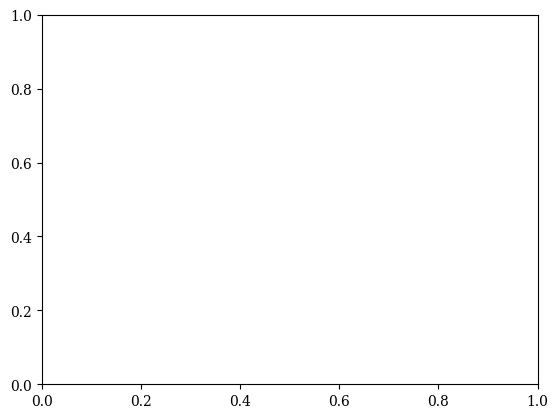

In [22]:
(extracted_results_all[0][1])

[(array([0.00000000e+00, 2.00803213e+06, 4.01606426e+06, 6.02409639e+06,
         8.03212851e+06, 1.00401606e+07, 1.20481928e+07, 1.40562249e+07,
         1.60642570e+07, 1.80722892e+07, 2.00803213e+07, 2.20883534e+07,
         2.40963855e+07, 2.61044177e+07, 2.81124498e+07, 3.01204819e+07,
         3.21285141e+07, 3.41365462e+07, 3.61445783e+07, 3.81526104e+07,
         4.01606426e+07, 4.21686747e+07, 4.41767068e+07, 4.61847390e+07,
         4.81927711e+07, 5.02008032e+07, 5.22088353e+07, 5.42168675e+07,
         5.62248996e+07, 5.82329317e+07, 6.02409639e+07, 6.22489960e+07,
         6.42570281e+07, 6.62650602e+07, 6.82730924e+07, 7.02811245e+07,
         7.22891566e+07, 7.42971888e+07, 7.63052209e+07, 7.83132530e+07,
         8.03212851e+07, 8.23293173e+07, 8.43373494e+07, 8.63453815e+07,
         8.83534137e+07, 9.03614458e+07, 9.23694779e+07, 9.43775100e+07,
         9.63855422e+07, 9.83935743e+07, 1.00401606e+08, 1.02409639e+08,
         1.04417671e+08, 1.06425703e+08, 1.08433735

/tmp/ipykernel_1474781/1410377563.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Agent", y="# Visited States", data=df, palette="Blues")


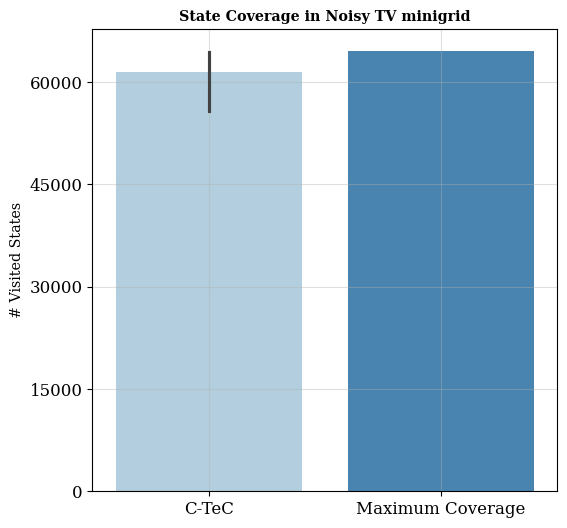

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
plt.rcParams["font.family"] = "serif"

values = [
    {"Agent": "C-TeC", "# Visited States": 55734},
    {"Agent": "C-TeC", "# Visited States": 64048},
    {"Agent": "C-TeC", "# Visited States": 64516},

    {"Agent": "Maximum Coverage", "# Visited States": 64516},
    {"Agent": "Maximum Coverage", "# Visited States": 64516},
    {"Agent": "Maximum Coverage", "# Visited States": 64516},
]

df = pd.DataFrame(values)
plt.figure(figsize=(6, 6))
ax = sns.barplot(x="Agent", y="# Visited States", data=df, palette="Blues")

fontSize = 10.3
plt.grid(which ='major', alpha = 0.4)
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Try changing nbins
ax.tick_params(axis='x', labelsize=12)  # x-axis ticks
ax.tick_params(axis='y', labelsize=12)
plt.title("State Coverage in Noisy TV minigrid", fontweight='bold', fontsize=fontSize)
plt.xlabel("")
plt.ylabel("# Visited States",fontsize=fontSize)
plt.savefig("noisy_tv_state_coverage.pdf", dpi=300, bbox_inches='tight')
plt.savefig("noisy_tv_state_coverage.png", dpi=300, bbox_inches='tight')